In [28]:
## Imports 

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_v1 = pd.read_csv("dataset version 1 (v1).")
train_data_v1 = pd.read_csv("train dataset(v1)")
test_data_v1 = pd.read_csv("test dataset(v1)")

In [2]:
## Check head

data_v1.head()

,Unnamed: 0,athlete_id,name,region,team,affiliate,gender,age,height,weight,...,deadlift,backsq,pullups,eat,train,background,experience,schedule,howlong,total lift
0,0,2554.0,Pj Ablang,South West,Double Edge,Double Edge CrossFit,Male,24.0,70.0,166.0,...,400.0,305.0,NaN,NaN,I workout mostly at a CrossFit Affiliate|I hav...,I played youth or high school level sports|I r...,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 2x a week|,4+ years|,NaN
1,1,3517.0,Derek Abdella,NaN,NaN,NaN,Male,42.0,70.0,190.0,...,NaN,NaN,NaN,NaN,I have a coach who determines my programming|I...,I played youth or high school level sports|,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 2x a week|,4+ years|,NaN
2,2,4691.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,5164.0,Abo Brandon,Southern California,LAX CrossFit,LAX CrossFit,Male,40.0,67.0,NaN,...,375.0,325.0,25.0,I eat 1-3 full cheat meals per week|,I workout mostly at a CrossFit Affiliate|I hav...,I played youth or high school level sports|,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|,4+ years|,1145.0
4,4,5286.0,Bryce Abbey,NaN,NaN,NaN,Male,32.0,65.0,149.0,...,NaN,325.0,50.0,I eat quality foods but don't measure the amount|,I workout mostly at a CrossFit Affiliate|I inc...,I played college sports|,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|I strictly s...,1-2 years|,NaN


In [3]:
## Check Columns

data_v1.columns

Index(['Unnamed: 0', 'athlete_id', 'name', 'region', 'team', 'affiliate',
       'gender', 'age', 'height', 'weight', 'fran', 'helen', 'grace',
       'filthy50', 'fgonebad', 'run400', 'run5k', 'candj', 'snatch',
       'deadlift', 'backsq', 'pullups', 'eat', 'train', 'background',
       'experience', 'schedule', 'howlong', 'total lift'],
      dtype='object')

In [4]:
## Check Shape

data_v1.shape, train_data_v1.shape, test_data_v1.shape

((423006, 29), (338404, 8), (84602, 8))

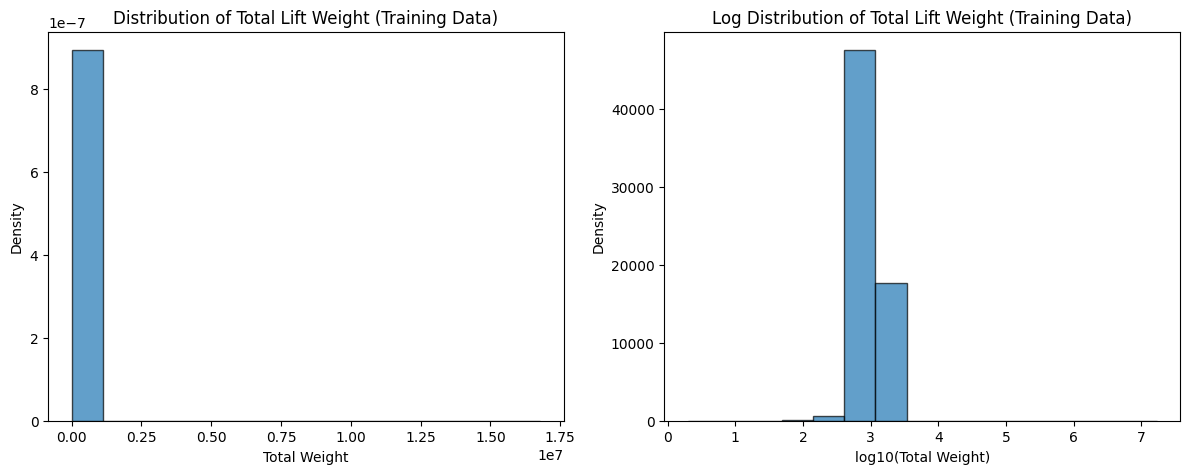

In [5]:
## Check distribution of total lifts(Train)

data = train_data_v1['total lift']
data_nonzero = data[data > 0]

plt.figure(figsize=(12, 5))

# Original distribution
plt.subplot(1, 2, 1)
plt.hist(data, bins=15, density=True, edgecolor='black', alpha=0.7)
plt.title('Distribution of Total Lift Weight (Training Data)')
plt.xlabel('Total Weight')
plt.ylabel('Density')

# Log-transformed distribution
plt.subplot(1, 2, 2)
plt.hist(np.log10(data_nonzero), bins=15, edgecolor='black', alpha=0.7)
plt.title('Log Distribution of Total Lift Weight (Training Data)')
plt.xlabel('log10(Total Weight)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

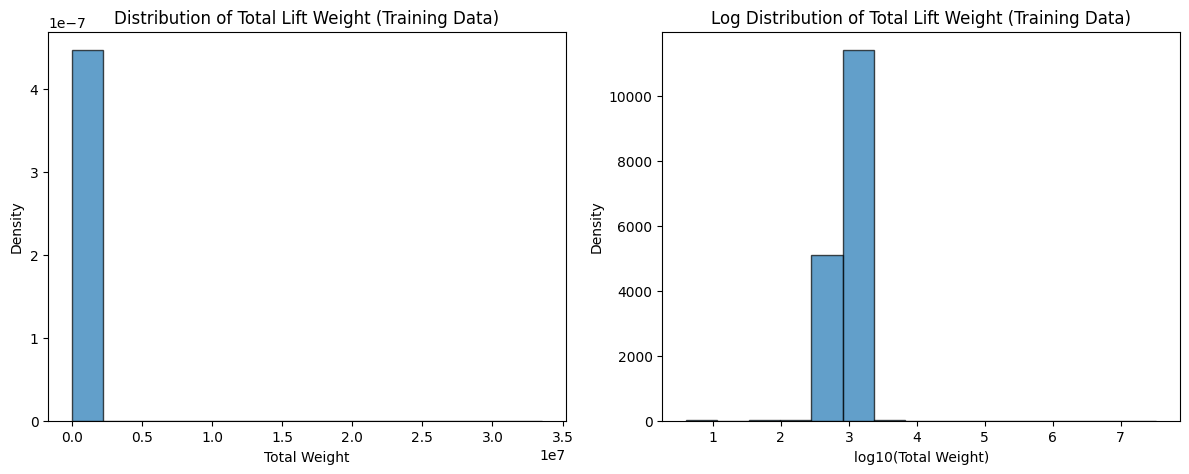

In [19]:
## Check distribution of total lifts(Test)

data = test_data_v1['total lift']
data_nonzero = data[data > 0]

plt.figure(figsize=(12, 5))

# Original distribution
plt.subplot(1, 2, 1)
plt.hist(data, bins=15, density=True, edgecolor='black', alpha=0.7)
plt.title('Distribution of Total Lift Weight (Training Data)')
plt.xlabel('Total Weight')
plt.ylabel('Density')

# Log-transformed distribution
plt.subplot(1, 2, 2)
plt.hist(np.log10(data_nonzero), bins=15, edgecolor='black', alpha=0.7)
plt.title('Log Distribution of Total Lift Weight (Training Data)')
plt.xlabel('log10(Total Weight)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [18]:
## Check Correlations

## Clean up

clean = data_v1.copy()

clean = clean.dropna(subset=['region','age','weight','height','howlong','gender','eat', \
                               'background','experience','schedule','howlong', \
                               'deadlift','candj','snatch','backsq','experience',\
                               'background','schedule','howlong'])

clean = clean.drop(columns=['team', 'affiliate', 'name', 'athlete_id', 'fran', 'helen', \
                            'grace', 'filthy50', 'fgonebad','run400', 'run5k', 'pullups', 'region', \
                            'Unnamed: 0', 'gender', 'eat', 'train', 'background', 'experience', 'schedule', 'howlong'])


corr = clean.corr()
corr

,age,height,weight,candj,snatch,deadlift,backsq,total lift
age,1.000000,-0.005207,0.094445,-0.158509,-0.128907,-0.003827,-0.009858,-0.007030
height,-0.005207,1.000000,0.001734,-0.014976,-0.011362,-0.000073,-0.000064,-0.000093
weight,0.094445,0.001734,1.000000,0.442430,0.339906,0.003387,0.006583,0.005637
candj,-0.158509,-0.014976,0.442430,1.000000,0.656633,0.247521,0.364126,0.320477
snatch,-0.128907,-0.011362,0.339906,0.656633,1.000000,-0.010053,-0.003016,-0.006535
deadlift,-0.003827,-0.000073,0.003387,0.247521,-0.010053,1.000000,0.707239,0.948664
backsq,-0.009858,-0.000064,0.006583,0.364126,-0.003016,0.707239,1.000000,0.894537
total lift,-0.007030,-0.000093,0.005637,0.320477,-0.006535,0.948664,0.894537,1.000000


## Baseline Model

In [36]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

## Clean Up

trainv1 = train_data_v1.drop(['Unnamed: 0'], axis=1)
trainv1 = trainv1.dropna()

testv1 = test_data_v1.drop(['Unnamed: 0'], axis=1)
testv1 = testv1.dropna()

X_train = trainv1.drop(columns=['total lift'])
y_train = trainv1['total lift']

X_test = testv1.drop(columns=['total lift'])
y_test = testv1['total lift']


In [43]:
## Pipeline

cat_features = ['region', 'gender', 'howlong']
num_features = ['age', 'weight', 'height']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
], remainder='passthrough')

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['region', 'gender',
                                                   'howlong'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [47]:
## Save model

import pickle

# Save model
with open("trained_total_lift_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Model pipeline saved as 'trained_total_lift_model.pkl'")

✅ Model pipeline saved as 'trained_total_lift_model.pkl'


## Metrics

In [44]:
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

n = len(y_test)       
p = X_test.shape[1]   
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R²', 'Adjusted R²'],
    'Value': [mae, mse, rmse, mape, r2, adj_r2]
})

print("\n Model Performance on Test Set:")
print(metrics.to_string(index=False))


 Model Performance on Test Set:
     Metric         Value
        MAE  5.908012e+03
        MSE  1.464632e+11
       RMSE  3.827051e+05
       MAPE  1.032540e+17
         R² -8.459610e-03
Adjusted R² -9.194996e-03


In [46]:
metrics.to_csv("model_metrics.csv", index=False)
print("Metrics saved to 'model_metrics.csv'")

Metrics saved to 'model_metrics.csv'


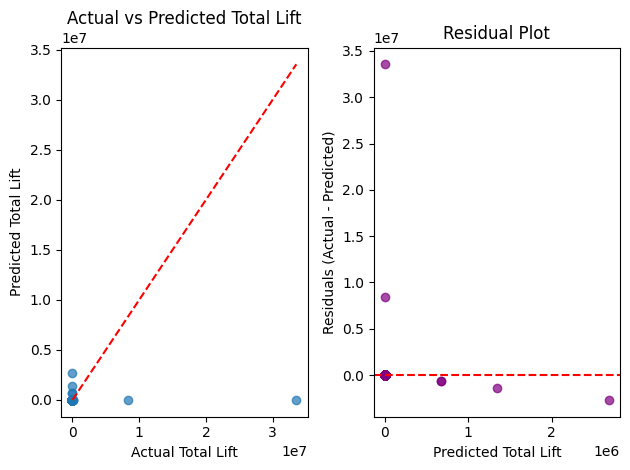

In [45]:
# 1️⃣ Actual vs Predicted Plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Total Lift")
plt.ylabel("Predicted Total Lift")
plt.title("Actual vs Predicted Total Lift")

# 2️⃣ Residuals Plot
residuals = y_test - y_pred
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.7, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Total Lift")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()